## NEURAL ODE

Using device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti with Max-Q Design
Generated speed data shape: torch.Size([1000, 1])
Speed data range: [0.13, 39.96]


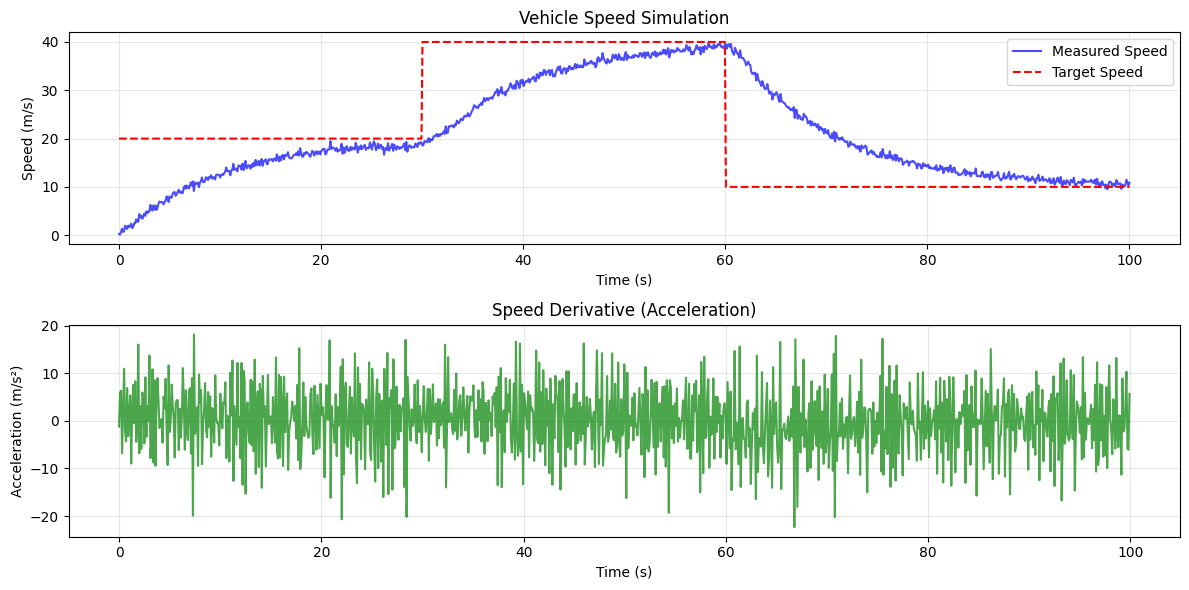


Data summary:
Time points: 1000
Speed mean: 20.95 ± 10.28


In [42]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    
# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Time steps: 0 to 100 seconds, sampled every 0.1s → 1000 points
t = torch.linspace(0, 100, 1000, device=device).reshape(-1, 1)


# True dynamics: ds/dt = -0.1*(s - target), where target changes over time
def true_speed_dynamics(t_numpy):
    t_numpy = np.atleast_1d(t_numpy)
    targets = np.zeros_like(t_numpy)
    targets[t_numpy < 30] = 20   # Accelerate to 20 m/s
    targets[(t_numpy >= 30) & (t_numpy < 60)] = 40  # Cruise at 40 m/s
    targets[t_numpy >= 60] = 10  # Decelerate to 10 m/s
    return targets


def ode_func(t_val, s):
    target = true_speed_dynamics(t_val) 
    return -0.1 * (s - target)

# Initial speed
s0 = 0.0

# Solve
t_numpy = t.cpu().flatten().numpy()
sol = solve_ivp(ode_func, [t_numpy.min(), t_numpy.max()], [s0], t_eval=t_numpy)

# Add small noise to simulate real data
speed_data = sol.y[0] + 0.5 * np.random.normal(size=len(sol.t))
speed_data = torch.tensor(speed_data, dtype=torch.float32, device=device).reshape(-1, 1)


print("Generated speed data shape:", speed_data.shape)
print(f"Speed data range: [{speed_data.min():.2f}, {speed_data.max():.2f}]")


plt.figure(figsize=(12, 6))


plt.subplot(2, 1, 1)
plt.plot(t_numpy, speed_data.cpu().numpy(), 'b-', alpha=0.7, label='Measured Speed')
plt.plot(t_numpy, true_speed_dynamics(t_numpy), 'r--', label='Target Speed')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Vehicle Speed Simulation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
speed_change = np.diff(speed_data.cpu().numpy().flatten()) / np.diff(t_numpy)
plt.plot(t_numpy[:-1], speed_change, 'g-', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')
plt.title('Speed Derivative (Acceleration)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

data_dict = {
    'time': t_numpy,
    'speed': speed_data.cpu().numpy().flatten(),
    'target': true_speed_dynamics(t_numpy)
}
print("\nData summary:")
print(f"Time points: {len(data_dict['time'])}")
print(f"Speed mean: {np.mean(data_dict['speed']):.2f} ± {np.std(data_dict['speed']):.2f}")

In [43]:
from torchdiffeq import odeint
import torch.nn as nn

In [44]:
class SpeedDynamics(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),  # input: speed
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)   # output: ds/dt
        )
    
    def forward(self, t, y):
        # y: current speed, t: time (not used here but required by odeint)
        return self.net(y)

class NeuralODEModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.dynamics = SpeedDynamics()
    
    def forward(self, y0, t):
        # Integrate the ODE from initial condition y0 over time t
        pred_y = odeint(self.dynamics, y0, t, method='dopri5')
        return pred_y

In [ ]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Prepare data
train_t = t  # full time span
train_y0 = speed_data[0].unsqueeze(0)  # initial speed
train_y_true = speed_data  # ground truth

# Create dataset
dataset = TensorDataset(train_t, train_y_true)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)  # We'll train on full sequence

# Model, loss, optimizer
model = NeuralODEModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()
    pred_y = model(train_y0, train_t.squeeze())  # Predict entire trajectory
    loss = criterion(pred_y.squeeze(), train_y_true.squeeze())
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 517.0844
Epoch 50, Loss: 124.9054
Epoch 100, Loss: 89.1281
Epoch 150, Loss: 80.1435
Epoch 200, Loss: 78.6641
Epoch 250, Loss: 78.2248
Epoch 300, Loss: 78.0051


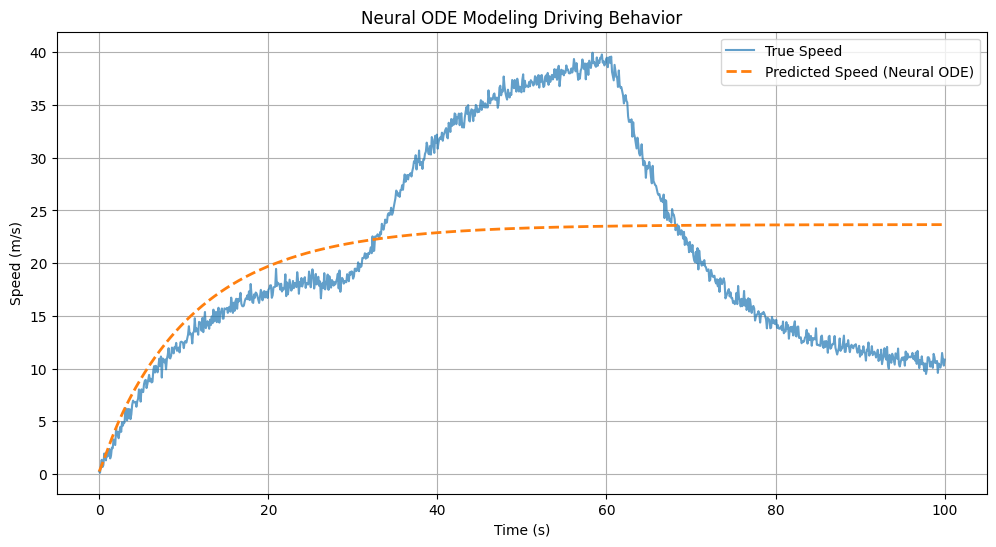

In [ ]:
with torch.no_grad():
    predicted_speed = model(train_y0, train_t.squeeze())

plt.figure(figsize=(12, 6))
plt.plot(train_t.numpy(), train_y_true.cpu().numpy(), label="True Speed", alpha=0.7)
plt.plot(train_t.numpy().squeeze(), predicted_speed.squeeze().cpu().numpy(), '--', label="Predicted Speed (Neural ODE)", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.title("Neural ODE Modeling Driving Behavior")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, 'neural_ode_model.pth')

print(f"\nTraining completed! Final loss: {loss.item():.4f}")


if torch.cuda.is_available():
    torch.cuda.empty_cache()